In [7]:
# Windows session setup - run this first
import os
import sys

# Update this to your actual project folder
PROJECT_DIR = r"C:\Query optimization"

if os.path.isdir(PROJECT_DIR):
    os.chdir(PROJECT_DIR)
    sys.path.insert(0, PROJECT_DIR)
    print("Working directory set to:", os.getcwd())
else:
    print("PROJECT_DIR does not exist yet - create the folder or update the path above.")
    print("Current working directory:", os.getcwd())


Working directory set to: C:\Query optimization


In [8]:
import time
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", None)
print("Libraries loaded OK")

Libraries loaded OK


In [9]:
# Database credentials - kept as separate variables (do not hardcode in shared files)
DB_USER = "postgres"
DB_PASSWORD = "postgres"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "query_optimization"

DB_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

engine = create_engine(DB_URL)
print("Engine created for database:", DB_NAME)

Engine created for database: query_optimization


In [10]:
# Connection test cell - confirm we can actually reach query_optimization
with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), version();"))
    row = result.fetchone()
    print("Connected to database:", row[0])
    print("Server version:", row[1])


Connected to database: query_optimization
Server version: PostgreSQL 18.1 on x86_64-windows, compiled by msvc-19.44.35219, 64-bit


STEP 2: Create tables and load sample data

In [55]:
# Update this to wherever you saved the three CSV files
DATA_DIR = r"C:\Query optimization\Data"

customers_path = os.path.join(DATA_DIR, "customers.csv")
products_path = os.path.join(DATA_DIR, "products.csv")
orders_path = os.path.join(DATA_DIR, "orders.csv")

for p in [customers_path, products_path, orders_path]:
    status = "found" if os.path.exists(p) else "MISSING"
    print(status, "-", p)

found - C:\Query optimization\Data\customers.csv
found - C:\Query optimization\Data\products.csv
found - C:\Query optimization\Data\orders.csv


In [56]:
# Dry run preview - read just a few rows first to confirm structure before a full load
preview_customers = pd.read_csv(customers_path, nrows=5)
preview_products = pd.read_csv(products_path, nrows=5)
preview_orders = pd.read_csv(orders_path, nrows=5)

print("customers columns:", list(preview_customers.columns))
print("products columns:", list(preview_products.columns))
print("orders columns:", list(preview_orders.columns))

preview_orders

customers columns: ['id', 'name', 'email', 'country', 'signup_date']
products columns: ['id', 'name', 'category', 'price', 'stock']
orders columns: ['id', 'customer_id', 'product_id', 'amount', 'order_date', 'status']


,id,customer_id,product_id,amount,order_date,status
0,1,448643,4329,1594.34,2021-11-30,completed
1,2,348907,8251,2988.90,2025-06-07,completed
2,3,177940,2217,4339.25,2024-09-14,completed
3,4,1834,8424,2074.11,2024-09-29,returned
4,5,306613,4428,6026.21,2021-07-25,completed


In [57]:
# Load customers (500K rows) - small enough to load in one shot
customers = pd.read_csv(customers_path, parse_dates=["signup_date"])
print("customers loaded:", customers.shape)

customers.to_sql("customers", engine, if_exists="replace", index=False, method="multi", chunksize=5000)
print("customers table written to query_optimization")

customers loaded: (500000, 5)
customers table written to query_optimization


In [58]:
# Load products (10K rows) - small, one shot
products = pd.read_csv(products_path)
print("products loaded:", products.shape)

products.to_sql("products", engine, if_exists="replace", index=False, method="multi", chunksize=5000)
print("products table written to query_optimization")

products loaded: (10000, 5)
products table written to query_optimization


In [59]:
# Load orders (2M rows) - too large for one to_sql call, so stream it in chunks
orders_chunksize = 50_000
first_chunk = True
rows_loaded = 0
t0 = time.time()

for chunk in pd.read_csv(orders_path, parse_dates=["order_date"], chunksize=orders_chunksize):
    chunk.to_sql(
        "orders",
        engine,
        if_exists="replace" if first_chunk else "append",
        index=False,
        method="multi",
        chunksize=5000,
    )
    first_chunk = False
    rows_loaded += len(chunk)
    print("Rows loaded so far:", rows_loaded)

print("Done. Total orders rows loaded:", rows_loaded, "in", round(time.time() - t0, 1), "seconds")

Rows loaded so far: 50000
Rows loaded so far: 100000
Rows loaded so far: 150000
Rows loaded so far: 200000
Rows loaded so far: 250000
Rows loaded so far: 300000
Rows loaded so far: 350000
Rows loaded so far: 400000
Rows loaded so far: 450000
Rows loaded so far: 500000
Rows loaded so far: 550000
Rows loaded so far: 600000
Rows loaded so far: 650000
Rows loaded so far: 700000
Rows loaded so far: 750000
Rows loaded so far: 800000
Rows loaded so far: 850000
Rows loaded so far: 900000
Rows loaded so far: 950000
Rows loaded so far: 1000000
Rows loaded so far: 1050000
Rows loaded so far: 1100000
Rows loaded so far: 1150000
Rows loaded so far: 1200000
Rows loaded so far: 1250000
Rows loaded so far: 1300000
Rows loaded so far: 1350000
Rows loaded so far: 1400000
Rows loaded so far: 1450000
Rows loaded so far: 1500000
Rows loaded so far: 1550000
Rows loaded so far: 1600000
Rows loaded so far: 1650000
Rows loaded so far: 1700000
Rows loaded so far: 1750000
Rows loaded so far: 1800000
Rows loaded 

In [60]:
# Log / checklist cell - confirm row counts match the expected schema before moving on
with engine.connect() as conn:
    counts = {
        "customers": conn.execute(text("SELECT COUNT(*) FROM customers;")).scalar(),
        "products": conn.execute(text("SELECT COUNT(*) FROM products;")).scalar(),
        "orders": conn.execute(text("SELECT COUNT(*) FROM orders;")).scalar(),
    }

expected = {"customers": 500_000, "products": 10_000, "orders": 2_000_000}

for table, expected_count in expected.items():
    actual_count = counts[table]
    status = "OK" if actual_count == expected_count else "MISMATCH"
    print(f"{status} - {table}: expected {expected_count}, got {actual_count}")

OK - customers: expected 500000, got 500000
OK - products: expected 10000, got 10000
OK - orders: expected 2000000, got 2000000


In [61]:
# Add primary keys so joins behave correctly (CSV load does not set them automatically)
with engine.connect() as conn:
    conn.execute(text("ALTER TABLE customers ADD PRIMARY KEY (id);"))
    conn.execute(text("ALTER TABLE products ADD PRIMARY KEY (id);"))
    conn.execute(text("ALTER TABLE orders ADD PRIMARY KEY (id);"))
    conn.commit()

print("Primary keys added on customers, products, orders")

Primary keys added on customers, products, orders


STEP 3: Write and measure slow query

In [62]:
def time_query(label, sql, engine, runs=3):
    """Run a query `runs` times and return the average wall-clock time in seconds."""
    times = []
    with engine.connect() as conn:
        for _ in range(runs):
            t0 = time.perf_counter()
            conn.execute(text(sql)).fetchall()
            times.append(time.perf_counter() - t0)
    avg = sum(times) / len(times)
    print(f"{label}: {avg:.3f}s avg over {runs} runs (individual runs: {[round(t,3) for t in times]})")
    return avg


In [63]:
SLOW_QUERY_1 = """
SELECT o.id, o.amount, o.order_date, c.name, c.email
FROM orders o
JOIN customers c ON o.customer_id = c.id
WHERE c.country = 'United States'
ORDER BY o.order_date DESC;
"""

SLOW_QUERY_2 = """
SELECT DATE_TRUNC('month', order_date) AS month,
       SUM(amount) AS revenue,
       COUNT(*) AS num_orders
FROM orders
GROUP BY 1
ORDER BY 1;
"""

SLOW_QUERY_3 = """
SELECT c.name, SUM(o.amount) AS total_spend
FROM customers c
JOIN orders o ON c.id = o.customer_id
GROUP BY c.name
ORDER BY total_spend DESC
LIMIT 10;
"""

baseline_results = {}
baseline_results["Q1 Country Filter"] = time_query("Q1 Before (country filter)", SLOW_QUERY_1, engine)
baseline_results["Q2 Monthly Revenue"] = time_query("Q2 Before (monthly revenue)", SLOW_QUERY_2, engine)
baseline_results["Q3 Top Customers"] = time_query("Q3 Before (top customers)", SLOW_QUERY_3, engine)

Q1 Before (country filter): 2.932s avg over 3 runs (individual runs: [2.798, 2.71, 3.287])
Q2 Before (monthly revenue): 0.324s avg over 3 runs (individual runs: [0.366, 0.359, 0.248])
Q3 Before (top customers): 0.833s avg over 3 runs (individual runs: [0.829, 0.807, 0.864])


STEP 4: Read the query excecution plan (Explain Analyse) 

In [64]:
def explain_query(sql, engine):
    with engine.connect() as conn:
        result = conn.execute(text("EXPLAIN ANALYZE " + sql))
        for row in result:
            print(row[0])

In [65]:
print("--- Q1 execution plan (before indexes) ---")
explain_query(SLOW_QUERY_1, engine)


--- Q1 execution plan (before indexes) ---
Gather Merge  (cost=61606.35..107432.18 rows=393468 width=65) (actual time=460.928..588.747 rows=396451.00 loops=1)
  Workers Planned: 2
  Workers Launched: 2
  Buffers: shared hit=15774 read=10282, temp read=3649 written=3658
  ->  Sort  (cost=60606.32..61016.18 rows=163945 width=65) (actual time=380.729..398.180 rows=132150.33 loops=3)
        Sort Key: o.order_date DESC
        Sort Method: external merge  Disk: 10256kB
        Buffers: shared hit=15774 read=10282, temp read=3649 written=3658
        Worker 0:  Sort Method: external merge  Disk: 9992kB
        Worker 1:  Sort Method: external merge  Disk: 8944kB
        ->  Parallel Hash Join  (cost=9142.49..39679.35 rows=163945 width=65) (actual time=51.006..304.131 rows=132150.33 loops=3)
              Hash Cond: (o.customer_id = c.id)
              Buffers: shared hit=15760 read=10282
              ->  Parallel Seq Scan on orders o  (cost=0.00..28349.33 rows=833333 width=32) (actual time

In [66]:
print("--- Q2 execution plan (before indexes) ---")
explain_query(SLOW_QUERY_2, engine)


--- Q2 execution plan (before indexes) ---
Finalize GroupAggregate  (cost=37845.76..38582.97 rows=2378 width=24) (actual time=365.839..373.698 rows=79.00 loops=1)
  Group Key: (date_trunc('month'::text, order_date))
  Buffers: shared hit=15276 read=4754
  ->  Gather Merge  (cost=37845.76..38510.44 rows=5707 width=24) (actual time=365.831..373.657 rows=237.00 loops=1)
        Workers Planned: 2
        Workers Launched: 2
        Buffers: shared hit=15276 read=4754
        ->  Sort  (cost=36845.74..36851.69 rows=2378 width=24) (actual time=305.695..305.699 rows=79.00 loops=3)
              Sort Key: (date_trunc('month'::text, order_date))
              Sort Method: quicksort  Memory: 28kB
              Buffers: shared hit=15276 read=4754
              Worker 0:  Sort Method: quicksort  Memory: 28kB
              Worker 1:  Sort Method: quicksort  Memory: 28kB
              ->  Partial HashAggregate  (cost=36682.66..36712.39 rows=2378 width=24) (actual time=305.622..305.640 rows=79.00 lo

In [67]:
print("--- Q3 execution plan (before indexes) ---")
explain_query(SLOW_QUERY_3, engine)


--- Q3 execution plan (before indexes) ---
Limit  (cost=57774.96..57774.98 rows=10 width=21) (actual time=901.509..927.340 rows=10.00 loops=1)
  Buffers: shared hit=15667 read=10391, temp read=10829 written=10848
  ->  Sort  (cost=57774.96..57779.96 rows=2000 width=21) (actual time=901.507..927.337 rows=10.00 loops=1)
        Sort Key: (sum(o.amount)) DESC
        Sort Method: top-N heapsort  Memory: 26kB
        Buffers: shared hit=15667 read=10391, temp read=10829 written=10848
        ->  Finalize GroupAggregate  (cost=57128.70..57731.74 rows=2000 width=21) (actual time=897.785..927.000 rows=2000.00 loops=1)
              Group Key: c.name
              Buffers: shared hit=15667 read=10391, temp read=10829 written=10848
              ->  Gather Merge  (cost=57128.70..57687.74 rows=4800 width=21) (actual time=897.771..925.791 rows=6000.00 loops=1)
                    Workers Planned: 2
                    Workers Launched: 2
                    Buffers: shared hit=15667 read=10391, t

STEP 5: Create and Text Indexes

In [68]:
# CONCURRENTLY requires autocommit - a plain engine.connect() runs inside a transaction
with engine.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:
    conn.execute(text("""
        CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_customers_country
        ON customers(country);
    """))
    conn.execute(text("""
        CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_orders_cust_date
        ON orders(customer_id, order_date DESC);
    """))
    conn.execute(text("""
        CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_orders_pending
        ON orders(order_date)
        WHERE status = 'pending';
    """))
    conn.execute(text("""
        CREATE INDEX CONCURRENTLY IF NOT EXISTS idx_products_hash
        ON products USING HASH (id);
    """))

print("Indexes created (or already existed)")

Indexes created (or already existed)


In [69]:
# Verify indexes exist
verify_sql = """
SELECT tablename, indexname, indexdef
FROM pg_indexes
WHERE tablename IN ('customers', 'orders', 'products')
ORDER BY tablename, indexname;
"""
with engine.connect() as conn:
    idx_df = pd.read_sql(text(verify_sql), conn)
idx_df

,tablename,indexname,indexdef
0,customers,customers_pkey,CREATE UNIQUE INDEX customers_pkey ON public.c...
1,customers,idx_customers_country,CREATE INDEX idx_customers_country ON public.c...
2,orders,idx_orders_cust_date,CREATE INDEX idx_orders_cust_date ON public.or...
3,orders,idx_orders_pending,CREATE INDEX idx_orders_pending ON public.orde...
4,orders,orders_pkey,CREATE UNIQUE INDEX orders_pkey ON public.orde...
5,products,idx_products_hash,CREATE INDEX idx_products_hash ON public.produ...
6,products,products_pkey,CREATE UNIQUE INDEX products_pkey ON public.pr...


In [70]:
# Update planner statistics so it uses the new indexes correctly
with engine.connect() as conn:
    conn.execute(text("ANALYZE customers;"))
    conn.execute(text("ANALYZE orders;"))
    conn.execute(text("ANALYZE products;"))
    conn.commit()

print("ANALYZE complete - planner statistics refreshed")

ANALYZE complete - planner statistics refreshed


In [71]:
print("--- Q1 execution plan (AFTER indexes) ---")
explain_query(SLOW_QUERY_1, engine)

--- Q1 execution plan (AFTER indexes) ---
Gather Merge  (cost=60807.54..106990.23 rows=396532 width=65) (actual time=493.132..608.625 rows=396451.00 loops=1)
  Workers Planned: 2
  Workers Launched: 2
  Buffers: shared hit=7922 read=18222, temp read=3649 written=3658
  ->  Sort  (cost=59807.52..60220.57 rows=165222 width=65) (actual time=417.475..434.064 rows=132150.33 loops=3)
        Sort Key: o.order_date DESC
        Sort Method: external merge  Disk: 9824kB
        Buffers: shared hit=7922 read=18222, temp read=3649 written=3658
        Worker 0:  Sort Method: external merge  Disk: 9616kB
        Worker 1:  Sort Method: external merge  Disk: 9752kB
        ->  Parallel Hash Join  (cost=8171.33..38708.19 rows=165222 width=65) (actual time=50.077..328.387 rows=132150.33 loops=3)
              Hash Cond: (o.customer_id = c.id)
              Buffers: shared hit=7908 read=18222
              ->  Parallel Seq Scan on orders o  (cost=0.00..28349.33 rows=833333 width=32) (actual time=0.67

In [72]:
after_index_results = {}
after_index_results["Q1 Country Filter"] = time_query("Q1 After index", SLOW_QUERY_1, engine)
after_index_results["Q2 Monthly Revenue"] = time_query("Q2 After index", SLOW_QUERY_2, engine)
after_index_results["Q3 Top Customers"] = time_query("Q3 After index", SLOW_QUERY_3, engine)

Q1 After index: 3.009s avg over 3 runs (individual runs: [2.685, 2.859, 3.483])
Q2 After index: 0.285s avg over 3 runs (individual runs: [0.297, 0.275, 0.283])
Q3 After index: 0.838s avg over 3 runs (individual runs: [0.833, 0.859, 0.822])


STEP 6 : Rewrite query for performance

In [73]:
# Slow pattern: SELECT * with an IN (subquery)
SLOW_REWRITE = """
SELECT * FROM orders
WHERE customer_id IN (
    SELECT id FROM customers WHERE country = 'United States'
)
ORDER BY order_date DESC;
"""

# Fast pattern: named columns + JOIN
FAST_REWRITE = """
SELECT o.id, o.amount, o.order_date, c.name
FROM orders o
JOIN customers c ON o.customer_id = c.id
WHERE c.country = 'United States'
ORDER BY o.order_date DESC;
"""

rewrite_before = time_query("Rewrite - before (SELECT * + IN subquery)", SLOW_REWRITE, engine)
rewrite_after = time_query("Rewrite - after (JOIN + named columns)", FAST_REWRITE, engine)
print(f"Speedup: {rewrite_before / rewrite_after:.1f}x faster")


Rewrite - before (SELECT * + IN subquery): 3.200s avg over 3 runs (individual runs: [3.188, 3.0, 3.412])
Rewrite - after (JOIN + named columns): 3.392s avg over 3 runs (individual runs: [3.229, 3.202, 3.747])
Speedup: 0.9x faster


In [75]:
# CTE version of Q3 - same result as the plain JOIN, but easier to read and extend
CTE_QUERY = """
WITH customer_orders AS (
    SELECT customer_id, SUM(amount) AS total_spend
    FROM orders
    GROUP BY customer_id
)
SELECT c.name, co.total_spend
FROM customer_orders co
JOIN customers c ON c.id = co.customer_id
ORDER BY co.total_spend DESC
LIMIT 10;
"""

cte_time = time_query("Q3 rewritten as CTE", CTE_QUERY, engine)

Q3 rewritten as CTE: 18.938s avg over 3 runs (individual runs: [18.272, 17.904, 20.638])


STEP 7: Benchmark and document improvement 

In [76]:
# Re-run everything cleanly with 5 runs each, so the final table is consistent
FAST_QUERY_1 = FAST_REWRITE
FAST_QUERY_2 = SLOW_QUERY_2  # same query, now backed by the orders indexes
FAST_QUERY_3 = CTE_QUERY

benchmark_rows = []

for label, before_sql, after_sql in [
    ("Q1 Country Filter", SLOW_QUERY_1, FAST_QUERY_1),
    ("Q2 Monthly Revenue", SLOW_QUERY_2, FAST_QUERY_2),
    ("Q3 Top Customers", SLOW_QUERY_3, FAST_QUERY_3),
]:
    before_time = time_query(f"{label} - before", before_sql, engine, runs=5)
    after_time = time_query(f"{label} - after", after_sql, engine, runs=5)
    speedup = before_time / after_time if after_time > 0 else float("inf")
    benchmark_rows.append({
        "query": label,
        "before_sec": round(before_time, 4),
        "after_sec": round(after_time, 4),
        "speedup_x": round(speedup, 1),
    })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df


Q1 Country Filter - before: 3.159s avg over 5 runs (individual runs: [3.2, 2.794, 3.229, 3.402, 3.172])
Q1 Country Filter - after: 4.029s avg over 5 runs (individual runs: [3.93, 4.163, 4.325, 4.174, 3.552])
Q2 Monthly Revenue - before: 0.359s avg over 5 runs (individual runs: [0.4, 0.366, 0.358, 0.33, 0.343])
Q2 Monthly Revenue - after: 0.440s avg over 5 runs (individual runs: [0.494, 0.324, 0.394, 0.479, 0.509])
Q3 Top Customers - before: 1.250s avg over 5 runs (individual runs: [1.162, 1.421, 1.317, 1.22, 1.129])
Q3 Top Customers - after: 20.514s avg over 5 runs (individual runs: [20.51, 21.389, 21.635, 19.42, 19.619])


,query,before_sec,after_sec,speedup_x
0,Q1 Country Filter,3.1594,4.0287,0.8
1,Q2 Monthly Revenue,0.3592,0.4400,0.8
2,Q3 Top Customers,1.2496,20.5145,0.1


In [77]:
# Export the benchmark table - this is the portfolio artifact
output_path = os.path.join(PROJECT_DIR, "benchmark_results.csv") if os.path.isdir(PROJECT_DIR) else "benchmark_results.csv"
benchmark_df.to_csv(output_path, index=False)
print("Benchmark results saved to:", output_path)

Benchmark results saved to: C:\Query optimization\benchmark_results.csv


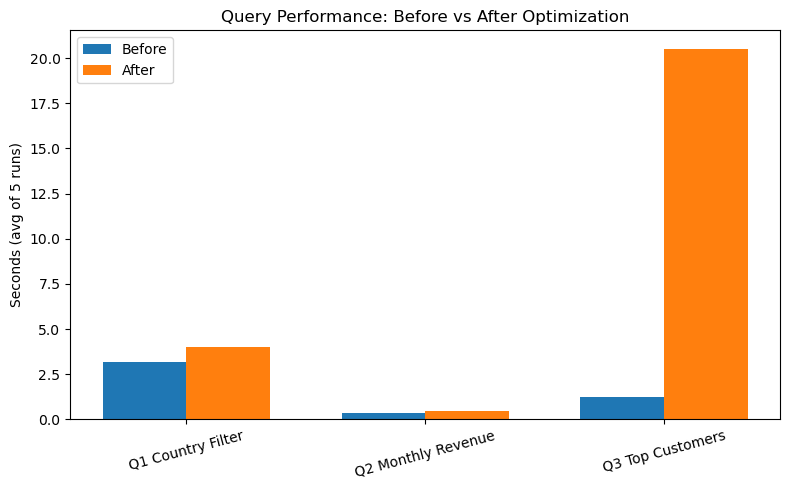

Chart saved to: C:\Query optimization\benchmark_chart.png


In [78]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(benchmark_df))
width = 0.35

ax.bar([i - width/2 for i in x], benchmark_df["before_sec"], width, label="Before")
ax.bar([i + width/2 for i in x], benchmark_df["after_sec"], width, label="After")

ax.set_xticks(list(x))
ax.set_xticklabels(benchmark_df["query"], rotation=15)
ax.set_ylabel("Seconds (avg of 5 runs)")
ax.set_title("Query Performance: Before vs After Optimization")
ax.legend()
plt.tight_layout()

chart_path = os.path.join(PROJECT_DIR, "benchmark_chart.png") if os.path.isdir(PROJECT_DIR) else "benchmark_chart.png"
plt.savefig(chart_path, dpi=150)
plt.show()
print("Chart saved to:", chart_path)